In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [5]:
df=pd.read_csv('WA_Fn-UseC_-HR-Employee-Attrition.csv')
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [6]:
# Dataset Shape
print("Rows and Columns:",df.shape)
# Column Names
print("\nColumn Names:\n",df.columns.tolist())
# Data Types
print("\nData Types:\n",df.dtypes)
# Missing Values
print("\nMissing Values:\n",df.isnull().sum())

Rows and Columns: (1470, 35)

Column Names:
 ['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department', 'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']

Data Types:
 Age                          int64
Attrition                   object
BusinessTravel              object
DailyRate                    int64
Department                  object
DistanceFromHome             int64
Education                    int64
EducationField              object
EmployeeCount                int64
Employe

Attrition
No     1233
Yes     237
Name: count, dtype: int64

Attrition Rate: 16.12 %


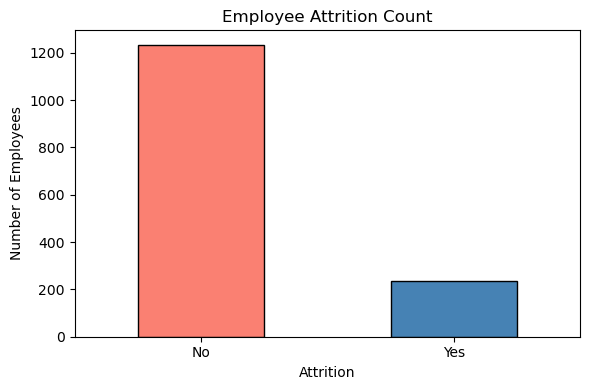

In [15]:
# How many employees left vs stayed
print(df['Attrition'].value_counts())
print("\nAttrition Rate:",round(df['Attrition'].value_counts(normalize=True)['Yes']*100,2),"%")

# Visualization
plt.figure(figsize=(6,4))
df['Attrition'].value_counts().plot(kind='bar',color=['salmon','steelblue'],edgecolor='black')
plt.title('Employee Attrition Count')
plt.xlabel('Attrition')
plt.ylabel('Number of Employees')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

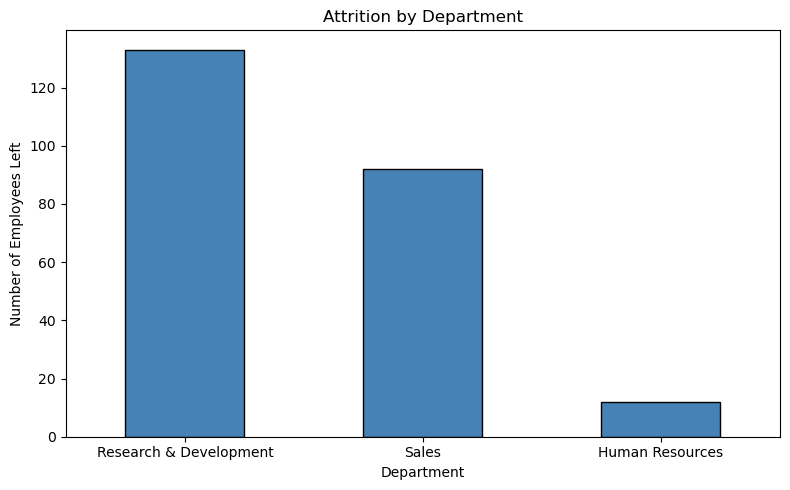

In [17]:
#Attrition by Department
plt.figure(figsize=(8,5))
dept_attrition=df[df['Attrition']=='Yes']['Department'].value_counts()
dept_attrition.plot(kind='bar',color='steelblue',edgecolor='black')
plt.title('Attrition by Department')
plt.xlabel('Department')
plt.ylabel('Number of Employees Left')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Average age of employees who left: 33.6
Average age of employees who stayed: 37.6


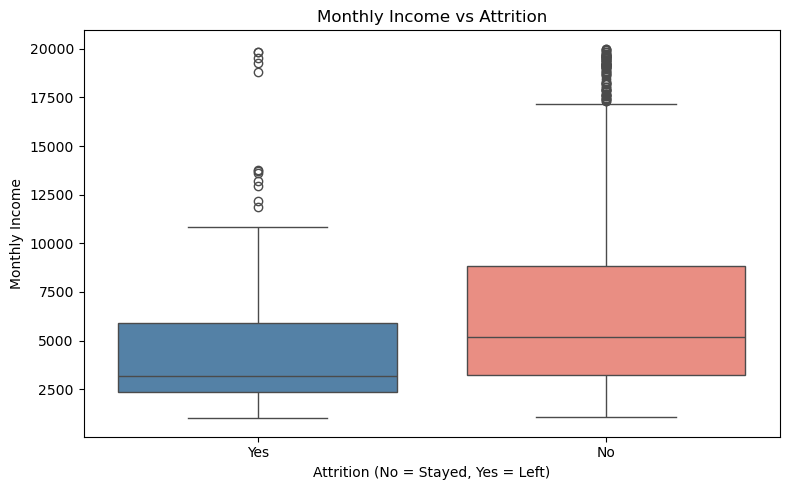


Avg Monthly Income - Left: 4787.0
Avg Monthly Income - Stayed: 6833.0


In [20]:
#Attrition by Age
print("Average age of employees who left:", round(df[df['Attrition']=='Yes']['Age'].mean(), 1))
print("Average age of employees who stayed:", round(df[df['Attrition']=='No']['Age'].mean(), 1))
# Income comparison
plt.figure(figsize=(8,5))
sns.boxplot(x='Attrition', y='MonthlyIncome', data=df, palette=['steelblue','salmon'])
plt.title('Monthly Income vs Attrition')
plt.xlabel('Attrition (No = Stayed, Yes = Left)')
plt.ylabel('Monthly Income')
plt.tight_layout()
plt.show()

print("\nAvg Monthly Income - Left:", round(df[df['Attrition']=='Yes']['MonthlyIncome'].mean(), 0))
print("Avg Monthly Income - Stayed:", round(df[df['Attrition']=='No']['MonthlyIncome'].mean(), 0))

<Figure size 700x500 with 0 Axes>

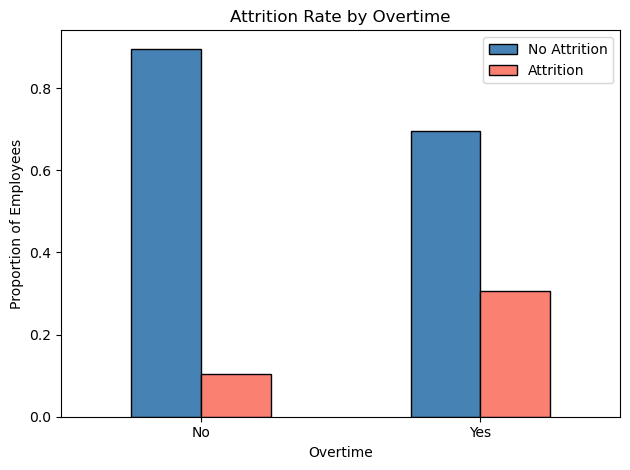

Attrition rate WITH overtime: 30.5%
Attrition rate WITHOUT overtime: 10.4%


In [21]:
#Attrition by OverTime
plt.figure(figsize=(7,5))
overtime_attrition = df.groupby('OverTime')['Attrition'].value_counts(normalize=True).unstack()
overtime_attrition.plot(kind='bar', color=['steelblue','salmon'], edgecolor='black')
plt.title('Attrition Rate by Overtime')
plt.xlabel('Overtime')
plt.ylabel('Proportion of Employees')
plt.xticks(rotation=0)
plt.legend(['No Attrition', 'Attrition'])
plt.tight_layout()
plt.show()

# Numbers
ot_yes=df[df['OverTime']=='Yes']['Attrition'].value_counts(normalize=True)['Yes']*100
ot_no=df[df['OverTime']=='No']['Attrition'].value_counts(normalize=True)['Yes']*100
print(f"Attrition rate WITH overtime: {round(ot_yes, 1)}%")
print(f"Attrition rate WITHOUT overtime: {round(ot_no, 1)}%")

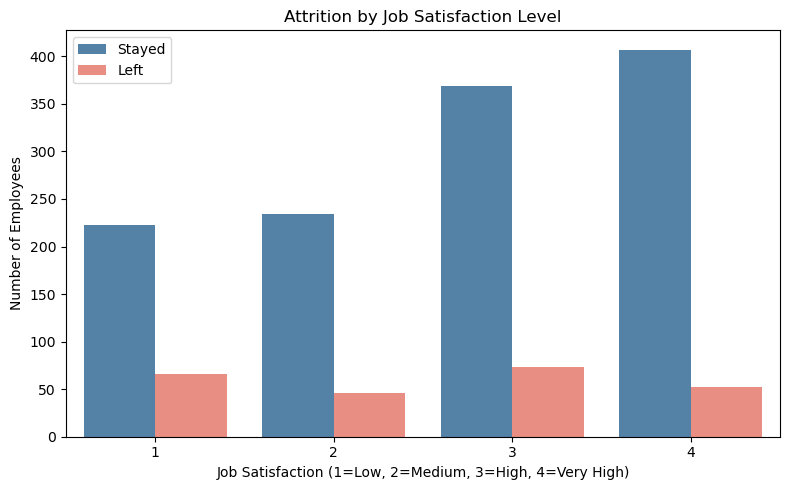

In [22]:
#Attrition by Job satisfaction
plt.figure(figsize=(8,5))
sns.countplot(x='JobSatisfaction', hue='Attrition', data=df, palette=['steelblue','salmon'])
plt.title('Attrition by Job Satisfaction Level')
plt.xlabel('Job Satisfaction (1=Low, 2=Medium, 3=High, 4=Very High)')
plt.ylabel('Number of Employees')
plt.legend(['Stayed', 'Left'])
plt.tight_layout()
plt.show()

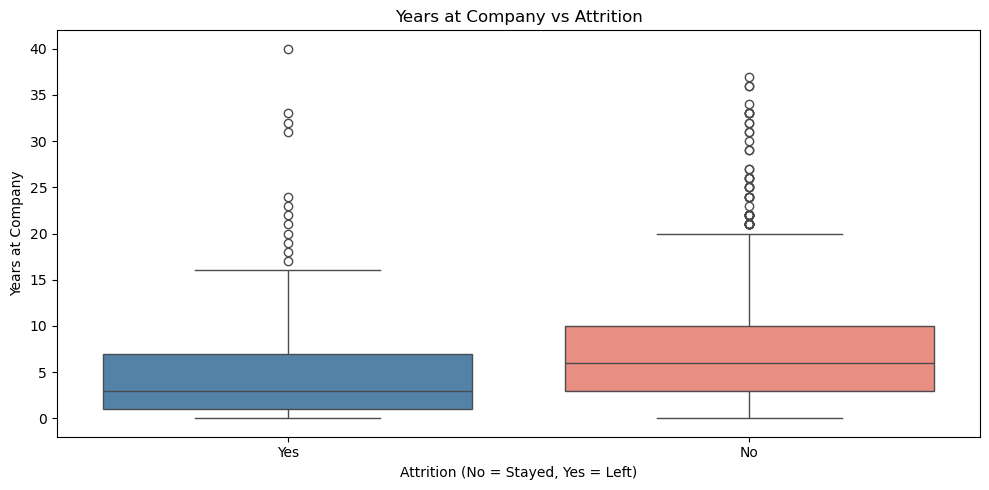

Avg years at company - Left: 5.1
Avg years at company - Stayed: 7.4


In [24]:
#Attrition by Years at company
plt.figure(figsize=(10,5))
sns.boxplot(x='Attrition', y='YearsAtCompany', data=df, palette=['steelblue','salmon'])
plt.title('Years at Company vs Attrition')
plt.xlabel('Attrition (No = Stayed, Yes = Left)')
plt.ylabel('Years at Company')
plt.tight_layout()
plt.show()

print("Avg years at company - Left:", round(df[df['Attrition']=='Yes']['YearsAtCompany'].mean(), 1))
print("Avg years at company - Stayed:", round(df[df['Attrition']=='No']['YearsAtCompany'].mean(), 1))

In [30]:
print("=" * 55)
print("      HR ATTRITION ANALYSIS - KEY FINDINGS")
print("=" * 55)
print(f"""
1. OVERALL ATTRITION RATE: 16.12%
   237 out of 1470 employees left the company

2. AGE:
   Employees who left were younger (avg 33.6 years)
   vs those who stayed (avg 37.6 years)

3. SALARY:
   Employees who left earned avg $4,787/month
   Employees who stayed earned avg $6,833/month
   → Low salary is the #1 reason for leaving

4. OVERTIME:
   Attrition WITH overtime:    30.5%
   Attrition WITHOUT overtime: 10.4%
   → Overtime employees are 3x more likely to leave

5. DEPARTMENT:
   R&D has the highest volume of employees leaving (133 people), but Sales has the highest percentage rate of attrition (20.6% vs R&D's 13.8%).

6. JOB SATISFACTION:
   Attrition rate drops steadily as satisfaction increases: 22.8% at Low (1) down to 11.3% at Very High (4).

7. YEARS AT COMPANY:
   Employees who left averaged only 5.1 years
   vs 7.4 years for those who stayed

CONCLUSION:
To reduce attrition, the company should:
  - Increase salaries for lower income employees
  - Reduce or compensate overtime work
  - Focus retention efforts on R&D department
  - Improve job satisfaction for younger employees
""")
print("=" * 55)

      HR ATTRITION ANALYSIS - KEY FINDINGS

1. OVERALL ATTRITION RATE: 16.12%
   237 out of 1470 employees left the company

2. AGE:
   Employees who left were younger (avg 33.6 years)
   vs those who stayed (avg 37.6 years)

3. SALARY:
   Employees who left earned avg $4,787/month
   Employees who stayed earned avg $6,833/month
   → Low salary is the #1 reason for leaving

4. OVERTIME:
   Attrition WITH overtime:    30.5%
   Attrition WITHOUT overtime: 10.4%
   → Overtime employees are 3x more likely to leave

5. DEPARTMENT:
   R&D has the highest volume of employees leaving (133 people), but Sales has the highest percentage rate of attrition (20.6% vs R&D's 13.8%).

6. JOB SATISFACTION:
   Attrition rate drops steadily as satisfaction increases: 22.8% at Low (1) down to 11.3% at Very High (4).

7. YEARS AT COMPANY:
   Employees who left averaged only 5.1 years
   vs 7.4 years for those who stayed

CONCLUSION:
To reduce attrition, the company should:
  - Increase salaries for lower in